In [1]:
from esda.moran_local_mv import MoranLocalPartial, MoranLocalConditional
from esda.moran import Moran_Local, Moran_Local_BV # standard Moran
from libpysal import graph # construct spatial relations
from scipy.stats import pearsonr # calculate correlation
import geopandas, geodatasets # work with spatial data
from matplotlib import pyplot as plt # visualize
import seaborn # further visualization tools
import numpy # math tools

In [2]:
df = geopandas.read_file(
    geodatasets.get_path("geoda.airbnb")
).dropna()

<Axes: >

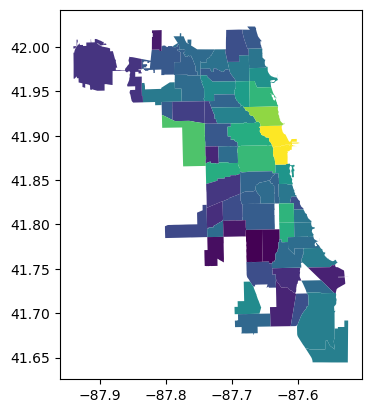

In [3]:
df.plot("price_pp")

In [4]:
y = df.price_pp.values.reshape(-1,1)
x = df.crowded.values.reshape(-1,1)
w = graph.Graph.build_contiguity(df).transform("R")

In [5]:
# are expensive places near expensive places?
Iy = Moran_Local(y, w)
# are crowded plcaes near crowded places?
Ix = Moran_Local(x, w) 
# are expensive places also crowded places? 
rho = pearsonr(y.squeeze(),x.squeeze())[0]
# are expensive places near crowded places?
Ixy = Moran_Local_BV(x, y, w) 
# are crowded places near expensive places?
Iyx = Moran_Local_BV(y, x, w)
# are expensive places near expensive places, adjusted for crowding?
p_lmo = MoranLocalPartial().fit(x,y,w)
# assuming crowding explains price, 
# are places with high post-crowding premiums near one another?
a_lmo = MoranLocalConditional().fit(x,y,w)

# this is a scaling factor for the multivariable statistics
scaling = (w.n - 1)/(w.n) * (1/(1-rho**2))

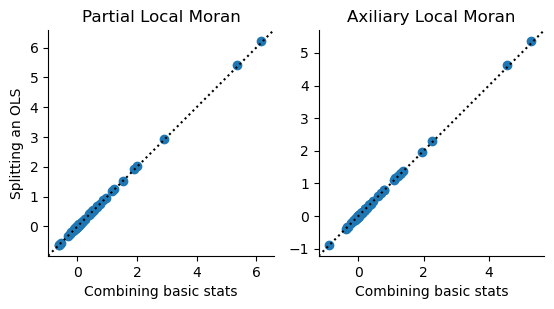

In [6]:
f,ax = plt.subplots(1,2, subplot_kw=dict(aspect='equal'))

ax[0].scatter(
    (Iy.Is - rho * Ixy.Is)*scaling, 
    p_lmo.association_
)

ax[1].scatter(
    (Iy.Is - rho*Ixy.Is - rho*Iyx.Is + rho**2*Ix.Is)*scaling,
    a_lmo.association_)

for i in range(2):
    xmin, xmax = ax[i].get_xlim()
    ymin, ymax = ax[i].get_ylim()
    left = min([xmin, ymin])
    right = max([xmax, ymax])
    ax[i].plot([left, right], [left, right], color='k', linestyle=":")
    ax[i].set_xlim(left, right)
    ax[i].set_ylim(left, right)
    if i==0:
        ax[i].set_ylabel("Splitting an OLS")
    ax[i].set_xlabel("Combining basic stats")
    ax[i].set_title(['Partial Local Moran', 'Axiliary Local Moran'][i])
    seaborn.despine(ax=ax[i])

In [7]:
#| echo: false
def quadcolor(x,y, colors=None):
    off_sign = numpy.sign(y) != numpy.sign(x)
    neg_y = y < 0
    quad = off_sign + neg_y*2
    if colors is None:
        colors= numpy.array(['red','powderblue','steelblue','lightsalmon'])
    return colors[quad]

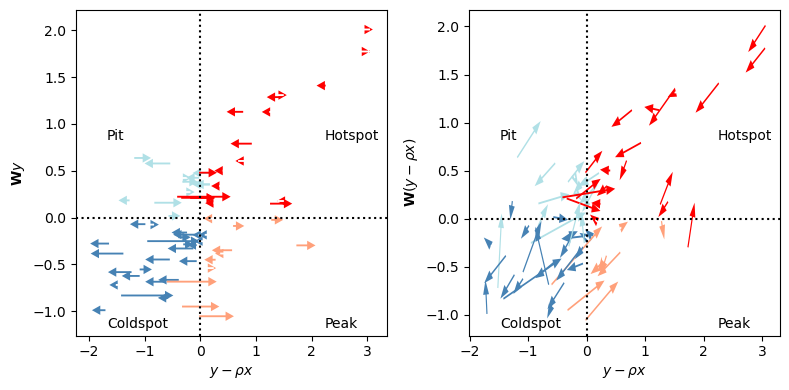

In [8]:
#| echo: false
f,ax = plt.subplots(1,2,figsize=(8,4))
for i,ax_ in enumerate(ax):
    start_x, start_y = Iy.z, Iy.w.sparse @ Iy.z
    new_x, new_y = (p_lmo.partials_.T, a_lmo.partials_.T)[i]
    dx, dy = new_x - start_x, new_y - start_y
    colors = quadcolor(new_x, new_y)
    for j in range(Iy.w.n):
        ax_.arrow(
            x=start_x[j], y=start_y[j],
            dx = dx[j], dy = dy[j],
            width=.02, shape='full', 
            length_includes_head=True, linewidth=0,
            head_width=.1, color=colors[j]
        )
    ax_.axvline(0, color='k', linestyle=':')
    ax_.axhline(0, color='k', linestyle=':')
    for j in range(2):
        for k in range(2):
            ax_.annotate(
                text=['Hotspot', 'Pit', 'Peak', 'Coldspot'][j+2*k],
                xy=(.1 if j else .8,
                    .025 if k else .6
                   ),
                xycoords="axes fraction"
            )
    ax_.set_xlabel(r"$y-\rho x$")
    ax_.set_ylabel((r"$\mathbf{W}y$", r"$\mathbf{W}(y-\rho x)$")[i])
f.tight_layout()
plt.show()

In [9]:
#| echo: false
def circular_hist(ax, x, bins=16, density=True, offset=0, gaps=True):
    """
    Produce a circular histogram of angles on ax.

    Parameters
    ----------
    ax : matplotlib.axes._subplots.PolarAxesSubplot
        axis instance created with subplot_kw=dict(projection='polar').

    x : array
        Angles to plot, expected in units of radians.

    bins : int, optional
        Defines the number of equal-width bins in the range. The default is 16.

    density : bool, optional
        If True plot frequency proportional to area. If False plot frequency
        proportional to radius. The default is True.

    offset : float, optional
        Sets the offset for the location of the 0 direction in units of
        radians. The default is 0.

    gaps : bool, optional
        Whether to allow gaps between bins. When gaps = False the bins are
        forced to partition the entire [-pi, pi] range. The default is True.

    Returns
    -------
    n : array or list of arrays
        The number of values in each bin.

    bins : array
        The edges of the bins.

    patches : `.BarContainer` or list of a single `.Polygon`
        Container of individual artists used to create the histogram
        or list of such containers if there are multiple input datasets.
    """
    np = numpy
    # Wrap angles to [-pi, pi)
    x = (x+np.pi) % (2*np.pi) - np.pi

    # Force bins to partition entire circle
    if not gaps:
        bins = np.linspace(-np.pi, np.pi, num=bins+1)

    # Bin data and record counts
    n, bins = np.histogram(x, bins=bins)

    # Compute width of each bin
    widths = np.diff(bins)

    # By default plot frequency proportional to area
    if density:
        # Area to assign each bin
        area = n / x.size
        # Calculate corresponding bin radius
        radius = (area/np.pi) ** .5
    # Otherwise plot frequency proportional to radius
    else:
        radius = n

    # Plot data on ax
    patches = ax.bar(bins[:-1], radius, zorder=1, 
                     align='edge', width=widths, linewidth=1
                     )

    # Set the direction of the zero angle
    ax.set_theta_offset(offset)

    # Remove ylabels for area plots (they are mostly obstructive)
    if density:
        ax.set_yticks([])

    return n, bins, patches

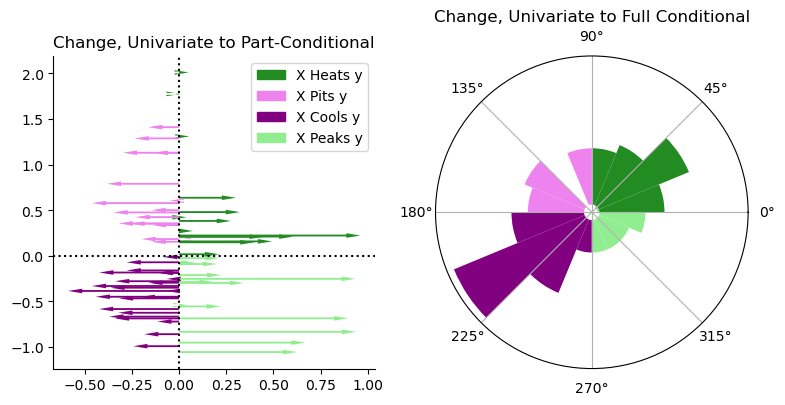

In [10]:
#| echo: false
f = plt.figure(figsize=(8,4))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2, projection='polar')
for i,ax_ in enumerate((ax1, ax2)):
    start_x, start_y = Iy.z, Iy.w.sparse @ Iy.z
    new_x, new_y = (p_lmo.partials_.T, a_lmo.partials_.T)[i]
    dx, dy = new_x - start_x, new_y - start_y
    colors = quadcolor(dx, dy if i > 0 else new_y,
                       colors=numpy.array(
                           ["forestgreen", 
                            "violet", 
                            "purple", 
                            "lightgreen"
                           ]
                       )
                      )
    if i == 0:
        for j in range(Iy.w.n):
            ax_.arrow(
                x=0, y=0 if i > 0 else start_y[j],
                dx = dx[j], dy = dy[j],
                width=.02, shape='full', 
                length_includes_head=True, linewidth=0,
                head_width=.05, color=colors[j]
            )
        ax_.axvline(0, color='k', linestyle=':')
        ax_.axhline(0, color='k', linestyle=':')
        ax1.set_title("Change, Univariate to Part-Conditional")
        seaborn.despine(ax=ax1)
        ax1.legend(
            handles = 
            [
                plt.arrow(0,0,1,0,
                          color=["forestgreen", "violet", "purple", "lightgreen"][i]) for i in range(4)
            ],
            labels = [
                "X Heats y", 
                "X Pits y", 
                "X Cools y", 
                "X Peaks y"
            ]
        )
    else:
        theta = numpy.arctan2(dy, dx)
        n, bins, patches = circular_hist(ax=ax2, x=theta, bins=16, gaps=False)
        for bin_, patch_ in zip(bins,patches.patches):
            if -numpy.pi/2 <= bin_ < 0:
                patch_.set_facecolor("lightgreen")
            elif 0 <= bin_ < numpy.pi/2:
                patch_.set_facecolor("forestgreen")
            elif numpy.pi/2 <= bin_ < numpy.pi:
                patch_.set_facecolor("violet")
            elif -numpy.pi <= bin_ < -numpy.pi/2:
                patch_.set_facecolor("purple")
        ax2.set_title("Change, Univariate to Full Conditional")
f.tight_layout()
plt.show()

In [11]:
#| echo: false
#| #| jupyter: {source_hidden: false}
import pandas

partial_moves = pandas.crosstab(
            Iy.q,
            p_lmo.labels_,
        )
partial_moves.columns = partial_moves.index = ['hotspot', 'pit', 'coldspot', 'peak']
partial_moves.columns.name = "Partial"
partial_moves.index.name = "Univariate"

aux_moves = pandas.crosstab(
            Iy.q,
            a_lmo.labels_,
        )
aux_moves.columns = aux_moves.index = ['hotspot', 'pit', 'coldspot', 'peak']
aux_moves.columns.name = "Auxiliary"
aux_moves.index.name = "Univariate"

In [12]:
#| echo: false
partial_moves

Partial,hotspot,pit,coldspot,peak
Univariate,,,,
hotspot,14,3,0,0
pit,4,9,0,0
coldspot,0,0,24,3
peak,0,0,1,8


In [13]:
#| echo: false
aux_moves

Auxiliary,hotspot,pit,coldspot,peak
Univariate,,,,
hotspot,14,3,0,0
pit,4,7,2,0
coldspot,0,5,19,3
peak,2,0,1,6
